## All-real, all-positive DV recipes

Search for Bruggeman HCM designs that support Dyakonov–Voigt waves using **only real,
positive constituent permittivities** (lossless case, optic axis in the interface
plane, $\chi = 0$).

DV requirement (RSPA **475**, 20190317, ineqs. 2.35): with $\epsilon_{ord}$ = HCM ordinary
value ($\epsilon_t^{HCM}$, the DV paper's $\epsilon_s$) and $\epsilon_{ax}$ = along-axis value
($\epsilon_z^{HCM}$, the DV paper's $\epsilon_t^{\mathcal A}$):

$$\epsilon_B \in \left(\epsilon_{ord},\ \tfrac{1}{2}(\epsilon_{ax}-\epsilon_{ord})\right)
\quad\Longrightarrow\quad \gamma = \epsilon_{ax}/\epsilon_{ord} > 3.$$

Three ingredients are all required: **(1)** needle-like prolate shape ($\alpha \lesssim 0.1$,
$\kappa \to 1$); **(2)** dilute fill $f_A \approx 0.2$–$0.3$ (below transverse percolation);
**(3)** constituent contrast $\gtrsim 50{:}1$ in the paper's exact setup (spherical
$\mathcal B$ particles), or $\gtrsim 20{:}1$ if both particle types are needle-shaped
(aligned fibrous microstructure — `bruggeman()` accepts `LtB`).

In [1]:
# All-real, all-positive DV recipes -- helpers.
# Requires bruggeman.py (this repo). Everything else is self-contained.
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from bruggeman import eps_hcm, bruggeman, Lt_doubly_truncated_spheroid, Lt_sphere

def psi_DV(eps_ord, eps_ax, eps_B):
    """Lossless DV propagation angle (deg) from dispersion eq. (2.29) of
    Mackay-Zhou-Lakhtakia, Proc. R. Soc. A 475, 20190317 (2019).

    Notation guard: eps_ord = HCM ordinary value  = eps_t^HCM = DV paper's eps_s
                    eps_ax  = HCM along-axis value = eps_z^HCM = DV paper's eps_t^A
    Returns np.nan if the DV constraints (2.35) fail.
    Validated: psi_DV(2, 6.5, 2.15) = 15.32 deg (paper's worked example)."""
    es, et, eB = float(eps_ord), float(eps_ax), float(eps_B)
    if not (eB > es and et - es > 2.0 * eB):
        return np.nan
    G = lambda c: (2*es*(eB+es) + (es-eB)*(es+et)*c
                   + 2*(es+eB)*np.sqrt(es*(es + (es-eB)*c)))
    c_lo = 2*es*(es+eB) / ((eB-es)*(es+et))     # bracket from ineqs (2.31)-(2.32)
    c_hi = es / (eB-es)
    c = brentq(G, c_lo*(1+1e-12), c_hi*(1-1e-12), xtol=1e-14)
    return np.degrees(np.arctan(1.0/np.sqrt(c)))

def dv_window(eps_ord, eps_ax):
    """(lo, hi) of the lossless-partner window eps_B in (eps_s, (eps_ax-eps_s)/2);
    empty (hi <= lo) unless gamma = eps_ax/eps_ord > 3."""
    return eps_ord, 0.5*(eps_ax - eps_ord)

def hcm_needles(eps_hi, eps_lo, fA, alpha=0.05, kappa=0.99, both=False):
    """Bruggeman HCM for needle-like prolate dt_spheroid A particles (real inputs).
    both=False: B particles spherical (paper's exact setup).
    both=True : B particles needle-shaped too (aligned fibrous microstructure)."""
    if not both:
        et, ez = eps_hcm(float(eps_hi), float(eps_lo), fA, "dt_spheroid",
                         kappa=kappa, alpha=alpha)
    else:
        LtN = lambda g: Lt_doubly_truncated_spheroid(g, kappa, alpha)
        et, ez, _ = bruggeman(float(eps_hi), float(eps_lo), fA, LtN, LtB=LtN)
    return et.real, ez.real          # (eps_ord, eps_ax); inputs real => outputs real


def img_hcm(eps_A, eps_B, fA, LtA, Lt_cav=Lt_sphere, N=20):
    """Incremental Maxwell Garnett HCM, eqs. (20)-(21) of JPCM 37, 045703.
    Shaped A particles (depolarization LtA) added into host B over N stages;
    Lt_cav = exclusion-region shape in eq. (20) (sphere in the paper).
    N=1 reduces exactly to the MG closed form, eq. (17)."""
    fB = 1.0 - fA
    et = ez = complex(eps_B)
    d = 1.0 - fB ** (1.0 / N)
    for _ in range(N):
        g = ez / et
        LtA_, Ltc = LtA(g), Lt_cav(g)
        LzA_, Lzc = 1/g - 2*LtA_, 1/g - 2*Ltc
        NtA, NzA = g*LtA_/et, g*LzA_/ez
        Ntc, Nzc = g*Ltc /et, g*Lzc /ez
        at = (eps_A - et)/(1 + NtA*(eps_A - et))
        az = (eps_A - ez)/(1 + NzA*(eps_A - ez))
        et = et + d*at/(1 - d*Ntc*at)
        ez = ez + d*az/(1 - d*Nzc*az)
    return et, ez

def img_converged(eps_A, eps_B, fA, LtA, Lt_cav=Lt_sphere, N0=10, tol=1e-3):
    """Double N until the infinity-norm change is below tol (paper's criterion)."""
    prev = img_hcm(eps_A, eps_B, fA, LtA, Lt_cav, N0)
    for N in (2*N0, 4*N0):
        cur = img_hcm(eps_A, eps_B, fA, LtA, Lt_cav, N)
        if max(abs(cur[0]-prev[0]), abs(cur[1]-prev[1])) < tol:
            return cur
        prev = cur
    return prev

def img_needles(eps_hi, eps_lo, fA, alpha=0.05, kappa=0.99, both=False):
    """IMG counterpart of hcm_needles. both=True uses a needle-shaped exclusion
    region (2D-MG analog of the fibrous microstructure)."""
    LtN = lambda g: Lt_doubly_truncated_spheroid(g, kappa, alpha)
    cav = LtN if both else Lt_sphere
    et, ez = img_converged(float(eps_hi), float(eps_lo), fA, LtN, Lt_cav=cav)
    return et.real, ez.real

assert abs(psi_DV(2.0, 6.5, 2.15) - 15.32) < 0.01
print("helpers loaded; psi_DV validation ok")


helpers loaded; psi_DV validation ok


In [2]:
# Contrast frontier: max gamma over fill fraction, needle shapes (alpha=0.05,
# kappa=0.99), host eps_lo = 1. DV needs gamma > 3.
fAs = np.linspace(0.05, 0.95, 37)
print(f"{'contrast':>9} | {'B=spheres (paper setup)':>26} | {'B=needles (fibrous)':>22}")
print("-" * 65)
for r in (10, 16, 20, 25, 33, 50, 100):
    g1 = max((hcm_needles(r, 1, f)[1] / hcm_needles(r, 1, f)[0], f) for f in fAs)
    g2 = max((hcm_needles(r, 1, f, both=True)[1] / hcm_needles(r, 1, f, both=True)[0], f)
             for f in fAs)
    m1 = "  <-- DV" if g1[0] > 3 else ""
    m2 = "  <-- DV" if g2[0] > 3 else ""
    print(f"{r:>7}:1 | gamma={g1[0]:5.2f} @ fA={g1[1]:.2f}{m1:<9} | "
          f"gamma={g2[0]:5.2f} @ fA={g2[1]:.2f}{m2}")


 contrast |    B=spheres (paper setup) |    B=needles (fibrous)
-----------------------------------------------------------------
     10:1 | gamma= 1.61 @ fA=0.22          | gamma= 1.97 @ fA=0.30
     16:1 | gamma= 2.00 @ fA=0.22          | gamma= 2.66 @ fA=0.27
     20:1 | gamma= 2.24 @ fA=0.22          | gamma= 3.12 @ fA=0.27  <-- DV
     25:1 | gamma= 2.52 @ fA=0.22          | gamma= 3.68 @ fA=0.27  <-- DV
     33:1 | gamma= 2.94 @ fA=0.22          | gamma= 4.55 @ fA=0.27  <-- DV
     50:1 | gamma= 3.72 @ fA=0.22  <-- DV  | gamma= 6.33 @ fA=0.27  <-- DV
    100:1 | gamma= 5.52 @ fA=0.22  <-- DV  | gamma=11.16 @ fA=0.27  <-- DV


In [3]:
# Same contrast frontier, incremental Maxwell Garnett (eqs. 20-21).
# Unlike Bruggeman, the exclusion-region (cavity) shape barely matters here: in
# the many-stage limit IMG becomes a differential scheme and the cavity term is
# second order in the increment, so the two columns nearly coincide. IMG predicts
# a lower DV threshold (~20:1) than Bruggeman in the paper setup, consistent with
# MG-type formalisms preserving more anisotropy for host-inclusion morphologies.
fAs = np.linspace(0.05, 0.95, 37)
print(f"{'contrast':>9} | {'sph. cavity (paper eq. 20)':>28} | {'needle cavity (fibrous)':>24}")
print("-" * 70)
for r in (10, 16, 20, 25, 33, 50, 100):
    g1 = max((img_needles(r, 1, f)[1] / img_needles(r, 1, f)[0], f) for f in fAs)
    g2 = max((img_needles(r, 1, f, both=True)[1] / img_needles(r, 1, f, both=True)[0], f)
             for f in fAs)
    m1 = "  <-- DV" if g1[0] > 3 else ""
    m2 = "  <-- DV" if g2[0] > 3 else ""
    print(f"{r:>7}:1 | gamma={g1[0]:6.2f} @ fA={g1[1]:.2f}{m1:<9} | "
          f"gamma={g2[0]:6.2f} @ fA={g2[1]:.2f}{m2}")


 contrast |   sph. cavity (paper eq. 20) |  needle cavity (fibrous)
----------------------------------------------------------------------
     10:1 | gamma=  2.15 @ fA=0.37          | gamma=  2.12 @ fA=0.37
     16:1 | gamma=  2.98 @ fA=0.37          | gamma=  2.93 @ fA=0.35
     20:1 | gamma=  3.53 @ fA=0.37  <-- DV  | gamma=  3.47 @ fA=0.35  <-- DV
     25:1 | gamma=  4.21 @ fA=0.35  <-- DV  | gamma=  4.12 @ fA=0.35  <-- DV
     33:1 | gamma=  5.26 @ fA=0.35  <-- DV  | gamma=  5.13 @ fA=0.35  <-- DV
     50:1 | gamma=  7.42 @ fA=0.35  <-- DV  | gamma=  7.19 @ fA=0.35  <-- DV
    100:1 | gamma= 13.19 @ fA=0.37  <-- DV  | gamma= 12.63 @ fA=0.37  <-- DV


In [4]:
# Shape sensitivity at contrast 25:1 (both-needles): alpha is the critical
# parameter, kappa barely matters once the particle is needle-like.
print(f"{'alpha':>6} {'kappa':>6} | max gamma")
for a, k in [(0.02,.99),(0.05,.99),(0.1,.99),(0.2,.99),(0.05,.9),(0.05,.7),(0.05,.5),(0.05,0.2)]:
    g = max(hcm_needles(25, 1, f, alpha=a, kappa=k, both=True)[1]
            / hcm_needles(25, 1, f, alpha=a, kappa=k, both=True)[0] for f in fAs)
    print(f"{a:>6} {k:>6} | {g:5.2f}" + ("   (gamma > 3)" if g > 3 else ""))


 alpha  kappa | max gamma
  0.02   0.99 |  3.83   (gamma > 3)
  0.05   0.99 |  3.68   (gamma > 3)
   0.1   0.99 |  3.35   (gamma > 3)
   0.2   0.99 |  2.75
  0.05    0.9 |  3.67   (gamma > 3)
  0.05    0.7 |  3.66   (gamma > 3)
  0.05    0.5 |  3.60   (gamma > 3)
  0.05    0.2 |  2.99


In [5]:
print(f"{'alpha':>6} {'kappa':>6} | max gamma")
for a, k in [(0.02,.99),(0.05,.99),(0.1,.99),(0.2,.99),(0.05,.9),(0.05,.7),(0.05,.5),(0.05,0.2)]:
    g = max(img_needles(25, 1, f, alpha=a, kappa=k, both=True)[1]
            / img_needles(25, 1, f, alpha=a, kappa=k, both=True)[0] for f in fAs)
    print(f"{a:>6} {k:>6} | {g:5.2f}" + ("   (gamma > 3)" if g > 3 else ""))

 alpha  kappa | max gamma
  0.02   0.99 |  4.33   (gamma > 3)
  0.05   0.99 |  4.12   (gamma > 3)
   0.1   0.99 |  3.69   (gamma > 3)
   0.2   0.99 |  2.93
  0.05    0.9 |  4.12   (gamma > 3)
  0.05    0.7 |  4.10   (gamma > 3)
  0.05    0.5 |  4.03   (gamma > 3)
  0.05    0.2 |  3.27   (gamma > 3)


In [6]:
# Three concrete all-real recipes, with DV window and propagation angle.
RECIPES = [
    dict(name="R1: eps=50 ceramic rods in air, B spheres (paper setup), THz/microwave",
         eps_hi=50.0, fA=0.22, both=False, partners=[(2.23, "eps_B=2.23")]),
    dict(name="R2: PbTe rods (eps=33) in air, both needles, mid-IR (4-20 um)",
         eps_hi=33.0, fA=0.27, both=True, partners=[(2.79, "eps_B=2.79")]),
    dict(name="R3: eps=100 ceramic, both needles, microwave/THz",
         eps_hi=100.0, fA=0.27, both=True,
         partners=[(2.25, "polyethylene"), (3.8, "fused silica"), (9.4, "alumina")]),
]
for R in RECIPES:
    eo, ea = hcm_needles(R["eps_hi"], 1.0, R["fA"], both=R["both"])
    lo, hi = dv_window(eo, ea)
    print(f"\n{R['name']}")
    print(f"   eps_ord = {eo:.3f}, eps_ax = {ea:.3f}, gamma = {ea/eo:.2f}, "
          f"eps_B window = ({lo:.2f}, {hi:.2f})")
    for eB, lab in R["partners"]:
        p = psi_DV(eo, ea, eB)
        print(f"   partner {lab:14s} (eps_B={eB}): psi_DV = {p:6.2f} deg, "
              f"q/k0 = {np.sqrt(eo)/np.cos(np.deg2rad(p)):.3f}")



R1: eps=50 ceramic rods in air, B spheres (paper setup), THz/microwave
   eps_ord = 1.893, eps_ax = 7.037, gamma = 3.72, eps_B window = (1.89, 2.57)
   partner eps_B=2.23     (eps_B=2.23): psi_DV =  22.94 deg, q/k0 = 1.494

R2: PbTe rods (eps=33) in air, both needles, mid-IR (4-20 um)
   eps_ord = 2.014, eps_ax = 9.165, gamma = 4.55, eps_B window = (2.01, 3.58)
   partner eps_B=2.79     (eps_B=2.79): psi_DV =  32.08 deg, q/k0 = 1.675

R3: eps=100 ceramic, both needles, microwave/THz
   eps_ord = 2.201, eps_ax = 24.591, gamma = 11.17, eps_B window = (2.20, 11.19)
   partner polyethylene   (eps_B=2.25): psi_DV =  11.29 deg, q/k0 = 1.513
   partner fused silica   (eps_B=3.8): psi_DV =  45.62 deg, q/k0 = 2.121
   partner alumina        (eps_B=9.4): psi_DV =  61.28 deg, q/k0 = 3.087


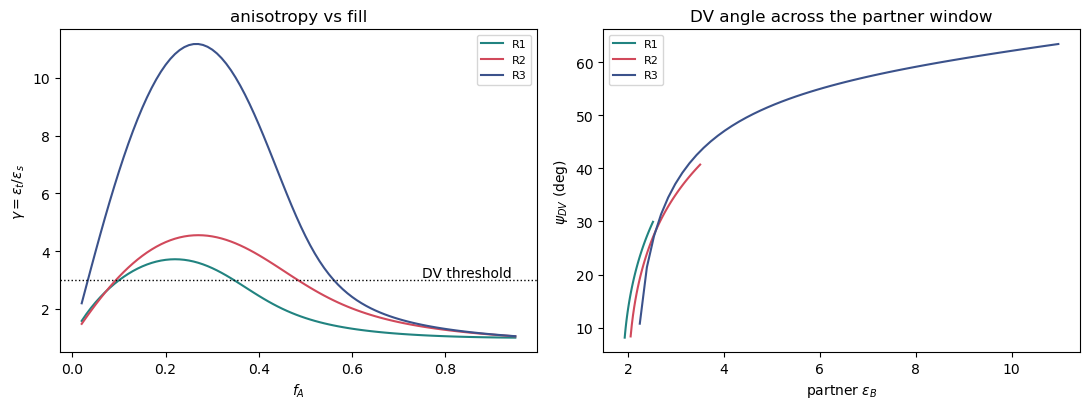

In [7]:
# Plots: (left) gamma vs fA with the DV threshold; (right) psi_DV across the
# partner window for each recipe.
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
fgrid = np.linspace(0.02, 0.95, 94)
for R, c in zip(RECIPES, ("#218380", "#d1495b", "#3b528b")):
    g = [hcm_needles(R["eps_hi"], 1, f, both=R["both"])[1]
         / hcm_needles(R["eps_hi"], 1, f, both=R["both"])[0] for f in fgrid]
    ax[0].plot(fgrid, g, color=c, label=R["name"].split(":")[0])
    eo, ea = hcm_needles(R["eps_hi"], 1.0, R["fA"], both=R["both"])
    lo, hi = dv_window(eo, ea)
    eBs = np.linspace(lo*1.02, hi*0.98, 60)
    ax[1].plot(eBs, [psi_DV(eo, ea, b) for b in eBs], color=c,
               label=R["name"].split(":")[0])
ax[0].axhline(3, color="k", ls=":", lw=1); ax[0].text(0.75, 3.1, "DV threshold")
ax[0].set_xlabel(r"$f_A$"); ax[0].set_ylabel(r"$\gamma=\epsilon_t/\epsilon_s$")
ax[0].legend(fontsize=8); ax[0].set_title("anisotropy vs fill")
ax[1].set_xlabel(r"partner $\epsilon_B$"); ax[1].set_ylabel(r"$\psi_{DV}$ (deg)")
ax[1].legend(fontsize=8); ax[1].set_title("DV angle across the partner window")
fig.tight_layout()
plt.show()


### DV-angle heat map over the $(f_A, \kappa)$ design plane

Left panel: $\psi_{DV}$ for a **fixed** lossless partner $\epsilon_B$ (gray = the window
$(\epsilon_{ord}, \tfrac{1}{2}(\epsilon_{ax}-\epsilon_{ord}))$ does not contain that
$\epsilon_B$ there). Right panel: the anisotropy $\gamma$ with the $\gamma = 3$ contour —
inside it a DV solution exists for *some* partner, so the gray/colored boundary on the
left moves as you change `EPS_B` but can never escape the $\gamma > 3$ region.

Note the near-vertical structure: in the needle regime ($\alpha \lesssim 0.1$) the
truncation parameter $\kappa$ has almost no influence — $f_A$ (and $\alpha$, contrast)
do the work. Edit the scenario block to switch recipes, e.g. `EPS_HI=50,
BOTH_NEEDLES=False, EPS_B=2.23` for the paper-setup recipe R1.

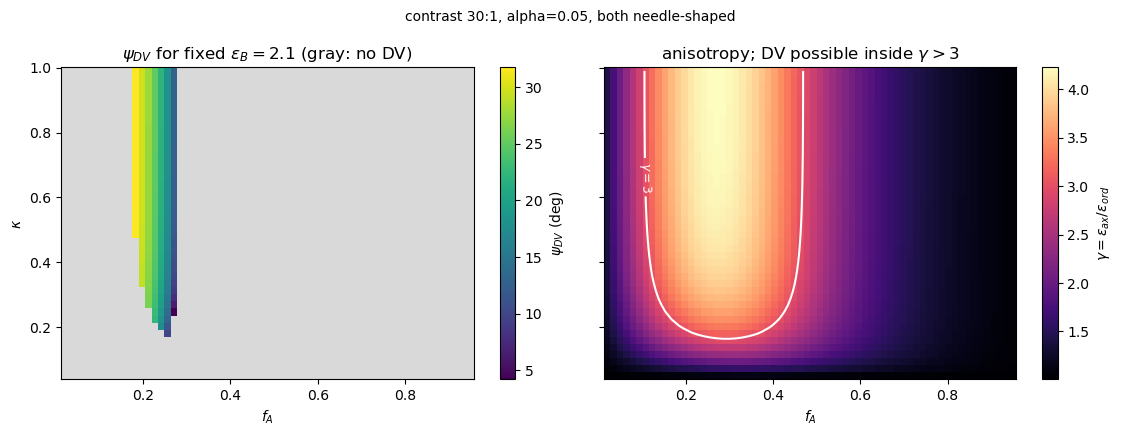

DV solutions at 235/2816 grid points; psi_DV range = [4.2, 31.7] deg


In [15]:
# ============================== CELL 6 ======================================
# Heat map of the DV propagation angle psi_DV over the (f_A, kappa) plane.
# Left: psi_DV for a FIXED lossless partner eps_B (gray = no DV solution there).
# Right: gamma = eps_ax/eps_ord with the gamma = 3 threshold contour, showing
# where a DV window exists for SOME partner.
import numpy as np
import matplotlib.pyplot as plt
from bruggeman import eps_hcm, bruggeman, Lt_doubly_truncated_spheroid

# ---- scenario (edit these) --------------------------------------------------
EPS_HI, EPS_LO = 30.0, 1.0     # constituent permittivities (real, positive)
ALPHA          = 0.05           # needle-like prolate A particles
BOTH_NEEDLES   = True           # False = paper's exact setup (B spheres)
EPS_B          = 2.1            # fixed lossless partner (e.g. fused silica)
# -----------------------------------------------------------------------------

fA_grid = np.linspace(0.02, 0.95, 64)
k_grid  = np.linspace(0.05, 0.99, 44)
PSI  = np.full((k_grid.size, fA_grid.size), np.nan)
GAM  = np.full_like(PSI, np.nan)

def psi_safe(eo, ea, eB):
    try:
        p = psi_DV(eo, ea, eB)
        return p
    except Exception:
        return np.nan

for i, k in enumerate(k_grid):
    LtN = lambda g: Lt_doubly_truncated_spheroid(g, k, ALPHA)
    for j, f in enumerate(fA_grid):
        if BOTH_NEEDLES:
            et, ez, _ = bruggeman(EPS_HI, EPS_LO, f, LtN, LtB=LtN)
        else:
            et, ez = eps_hcm(EPS_HI, EPS_LO, f, "dt_spheroid", kappa=k, alpha=ALPHA)
        eo, ea = et.real, ez.real
        GAM[i, j] = ea / eo
        PSI[i, j] = psi_safe(eo, ea, EPS_B)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)
cmap = plt.cm.viridis.copy(); cmap.set_bad("0.85")
pm = ax[0].pcolormesh(fA_grid, k_grid, np.ma.masked_invalid(PSI),
                      cmap=cmap, shading="auto")
fig.colorbar(pm, ax=ax[0], label=r"$\psi_{DV}$ (deg)")
ax[0].set_title(rf"$\psi_{{DV}}$ for fixed $\epsilon_B={EPS_B}$ (gray: no DV)")
ax[0].set_xlabel(r"$f_A$"); ax[0].set_ylabel(r"$\kappa$")

pm2 = ax[1].pcolormesh(fA_grid, k_grid, GAM, cmap="magma", shading="auto")
fig.colorbar(pm2, ax=ax[1], label=r"$\gamma=\epsilon_{ax}/\epsilon_{ord}$")
cs = ax[1].contour(fA_grid, k_grid, GAM, levels=[3.0], colors="w", linewidths=1.5)
ax[1].clabel(cs, fmt={3.0: r"$\gamma=3$"}, fontsize=9)
ax[1].set_title(r"anisotropy; DV possible inside $\gamma>3$")
ax[1].set_xlabel(r"$f_A$")
fig.suptitle(f"contrast {EPS_HI:g}:{EPS_LO:g}, alpha={ALPHA}, "
             f"{'both needle-shaped' if BOTH_NEEDLES else 'B spheres (paper setup)'}",
             fontsize=10)
fig.tight_layout()
plt.show()
ok = np.isfinite(PSI)
print(f"DV solutions at {ok.sum()}/{PSI.size} grid points; "
      f"psi_DV range = [{np.nanmin(PSI):.1f}, {np.nanmax(PSI):.1f}] deg")


### Bruggeman vs incremental Maxwell Garnett

Same $(f_A, \kappa)$ heat map computed with **both** homogenization formalisms, same
fixed partner $\epsilon_B$ and shared color scale. `img_hcm` implements eqs. (20)–(21)
of the Bruggeman paper: shaped $\mathcal A$ particles added incrementally into host
$\mathcal B$; with $N=1$ it reduces exactly to the MG closed form, eq. (17), and $N$ is
doubled until the paper's convergence criterion is met.

One mapping note: when `BOTH_NEEDLES=True` the Bruggeman run treats both particle types
as needles (`LtB`), and the IMG analog uses a needle-shaped exclusion region
(`Lt_cav`) — this reproduces the standard 2-D anisotropic MG in the aligned-cylinder
limit. With `BOTH_NEEDLES=False` both formalisms follow the paper's equations verbatim
(spherical $\mathcal B$ particles / spherical cavity).

Reading the comparison: IMG predicts a **larger** DV region and somewhat different
$\psi_{DV}$ — consistent with MG-type estimates giving higher anisotropy for
ordered rod-like morphologies, with Bruggeman the conservative bound. The two agree
well deep inside the region and diverge near the existence edge, so the
**intersection** of the two colored regions is the robust design set.

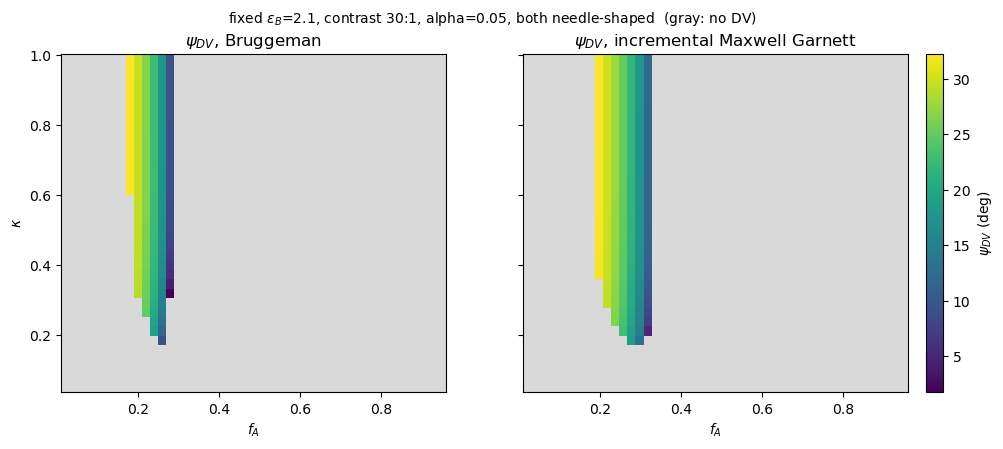

DV region: Br 156 pts, IMG 202 pts, overlap 136 pts
where both exist: mean |psi_Br - psi_IMG| = 6.57 deg, max = 18.95 deg


In [9]:
# ============================== CELL 7 ======================================
# Side-by-side heat maps of psi_DV over (f_A, kappa): Bruggeman vs incremental
# Maxwell Garnett (IMG, eqs. 20-21 of JPCM 37 045703), same fixed partner eps_B.
import numpy as np
import matplotlib.pyplot as plt
from bruggeman import (eps_hcm, bruggeman, Lt_doubly_truncated_spheroid, Lt_sphere)

# img_hcm / img_converged are defined in the helpers cell above

# ---- scenario (edit; keep consistent with the previous cell) ----------------
EPS_HI, EPS_LO = 30.0, 1.0
ALPHA          = 0.05
BOTH_NEEDLES   = True     # IMG analog: needle-shaped exclusion region (2D-MG limit)
EPS_B          = 2.1
# -----------------------------------------------------------------------------

fA_grid = np.linspace(0.02, 0.95, 48)
k_grid  = np.linspace(0.05, 0.99, 36)
PSI = {m: np.full((k_grid.size, fA_grid.size), np.nan) for m in ("Br", "IMG")}

for i, k in enumerate(k_grid):
    LtN = lambda g: Lt_doubly_truncated_spheroid(g, k, ALPHA)
    cav = LtN if BOTH_NEEDLES else Lt_sphere
    for j, f in enumerate(fA_grid):
        if BOTH_NEEDLES:
            eB_t, eB_z, _ = bruggeman(EPS_HI, EPS_LO, f, LtN, LtB=LtN)
        else:
            eB_t, eB_z = eps_hcm(EPS_HI, EPS_LO, f, "dt_spheroid", kappa=k, alpha=ALPHA)
        eI_t, eI_z = img_converged(EPS_HI, EPS_LO, f, LtN, Lt_cav=cav)
        for m, (eo, ea) in (("Br", (eB_t.real, eB_z.real)),
                            ("IMG", (eI_t.real, eI_z.real))):
            try:
                PSI[m][i, j] = psi_DV(eo, ea, EPS_B)
            except Exception:
                pass

vmin = min(np.nanmin(PSI[m]) for m in PSI)
vmax = max(np.nanmax(PSI[m]) for m in PSI)
cmap = plt.cm.viridis.copy(); cmap.set_bad("0.85")
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)
for a, m, ttl in zip(ax, ("Br", "IMG"), ("Bruggeman", "incremental Maxwell Garnett")):
    pm = a.pcolormesh(fA_grid, k_grid, np.ma.masked_invalid(PSI[m]),
                      cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
    a.set_title(rf"$\psi_{{DV}}$, {ttl}"); a.set_xlabel(r"$f_A$")
ax[0].set_ylabel(r"$\kappa$")
fig.colorbar(pm, ax=ax, label=r"$\psi_{DV}$ (deg)", fraction=0.03, pad=0.02)
fig.suptitle(f"fixed $\\epsilon_B$={EPS_B}, contrast {EPS_HI:g}:{EPS_LO:g}, "
             f"alpha={ALPHA}, "
             f"{'both needle-shaped' if BOTH_NEEDLES else 'B spheres (paper setup)'}"
             "  (gray: no DV)", fontsize=10)
plt.show()

both = np.isfinite(PSI["Br"]) & np.isfinite(PSI["IMG"])
print(f"DV region: Br {np.isfinite(PSI['Br']).sum()} pts, "
      f"IMG {np.isfinite(PSI['IMG']).sum()} pts, overlap {both.sum()} pts")
print(f"where both exist: mean |psi_Br - psi_IMG| = "
      f"{np.nanmean(np.abs(PSI['Br']-PSI['IMG'])[both]):.2f} deg, "
      f"max = {np.nanmax(np.abs(PSI['Br']-PSI['IMG'])[both]):.2f} deg")


1) derivative graph of above
2) dyakonov of some cases above
3) eps_t against f_A of IMG, BR for different kappa

### Caveats

- This needle–dilute corner is where Bruggeman and MG/IMG disagree most, so treat the
  numbers as morphology-sensitive estimates and cross-check against the IMG branch.
  The disagreement is favourable: for a fabricated *ordered* aligned-rod sample the
  MG-type estimate is the more faithful one and predicts even **higher** $\gamma$,
  so Bruggeman is the conservative choice here.
- "Lossless" at $\epsilon \sim 33$–$100$ means mid-IR PbTe or microwave/THz ceramics in
  practice; a small real $\tan\delta$ perturbs rather than destroys these solutions and
  can be quantified with the dissipative solver (`dv_dissipative.py`).
- $\psi_{DV}$ is the single in-plane propagation direction (per quadrant) measured from
  the projection of the composite's particle axis; the axis itself must lie **in** the
  interface plane ($\chi = 0$) for these lossless solutions.

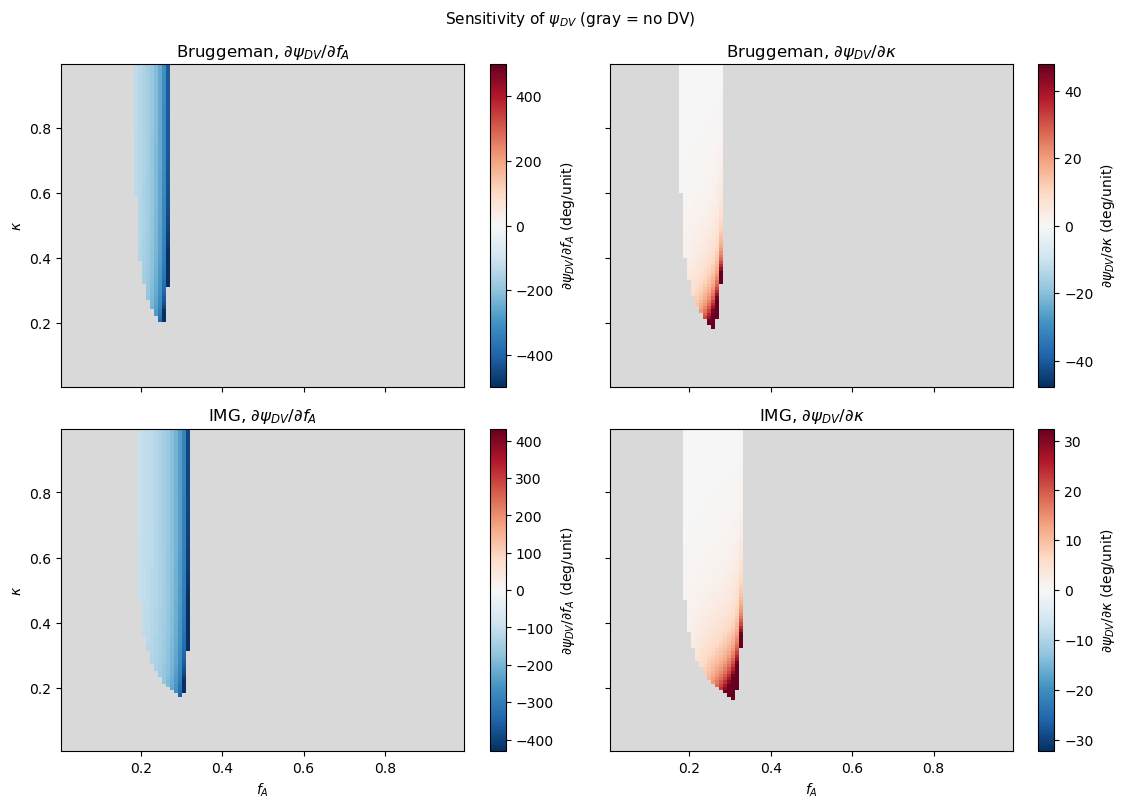

Br: median |dpsi/dfA| = 216.2 deg/unit, median |dpsi/dkappa| = 1.09 deg/unit
IMG: median |dpsi/dfA| = 160.1 deg/unit, median |dpsi/dkappa| = 0.82 deg/unit


In [12]:
import matplotlib.pyplot as plt
from bruggeman import bruggeman, Lt_doubly_truncated_spheroid, Lt_sphere
 
EPS_HI, EPS_LO, ALPHA, EPS_B = 30.0, 1.0, 0.05, 2.1
 
def br_pair(f, k):
    LtN = lambda g: Lt_doubly_truncated_spheroid(g, k, ALPHA)
    et, ez, _ = bruggeman(EPS_HI, EPS_LO, f, LtN, LtB=LtN)
    return et.real, ez.real
 
def img_pair(f, k):
    LtN = lambda g: Lt_doubly_truncated_spheroid(g, k, ALPHA)
    et, ez = img_converged(EPS_HI, EPS_LO, f, LtN, Lt_cav=LtN)
    return et.real, ez.real
 
fA_grid = np.linspace(0.01, 0.99, 100)
k_grid  = np.linspace(0.01, 0.99, 100)
PSI = {m: np.full((k_grid.size, fA_grid.size), np.nan) for m in ("Br", "IMG")}
for i, k in enumerate(k_grid):
    for j, f in enumerate(fA_grid):
        for m, hcm in (("Br", br_pair), ("IMG", img_pair)):
            PSI[m][i, j] = psi_DV(*hcm(f, k), EPS_B)
 
D = {m: dict(zip(("k", "f"), np.gradient(PSI[m], k_grid, fA_grid))) for m in PSI}
 
fig, ax = plt.subplots(2, 2, figsize=(11.5, 8.2), sharex=True, sharey=True)
cmap = plt.cm.RdBu_r.copy(); cmap.set_bad("0.85")
labels = {"f": r"$\partial\psi_{DV}/\partial f_A$", "k": r"$\partial\psi_{DV}/\partial\kappa$"}
for row, m in enumerate(("Br", "IMG")):
    for col, key in enumerate(("f", "k")):
        Z = np.ma.masked_invalid(D[m][key])
        v = np.nanpercentile(np.abs(D[m][key]), 98)
        pm = ax[row, col].pcolormesh(fA_grid, k_grid, Z, cmap=cmap, vmin=-v, vmax=v,
                                     shading="auto")
        fig.colorbar(pm, ax=ax[row, col], label=labels[key] + " (deg/unit)")
        ax[row, col].set_title(("Bruggeman" if m == "Br" else "IMG") + ", " + labels[key])
for a in ax[1]: a.set_xlabel(r"$f_A$")
for a in ax[:, 0]: a.set_ylabel(r"$\kappa$")
fig.suptitle(r"Sensitivity of $\psi_{DV}$ (gray = no DV)", fontsize=11)
fig.tight_layout(); plt.show()
for m in PSI:
    print(f"{m}: median |dpsi/dfA| = {np.nanmedian(np.abs(D[m]['f'])):.1f} deg/unit, "
          f"median |dpsi/dkappa| = {np.nanmedian(np.abs(D[m]['k'])):.2f} deg/unit")

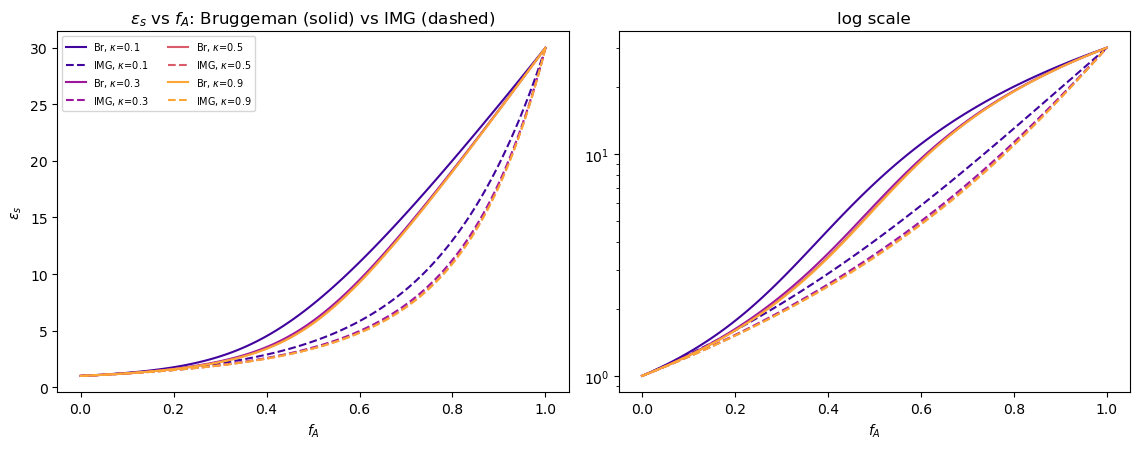

In [14]:
# eps_t (ordinary) vs f_A: Bruggeman (solid) vs IMG (dashed), several kappa.
fs = np.linspace(0.0, 1.0, 120)
kappas = (0.10, 0.30, 0.50, 0.90)
cols = plt.cm.plasma(np.linspace(0.1, 0.8, len(kappas)))
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.6))
for k, c in zip(kappas, cols):
    br_s = [br_pair(f, k)[0] for f in fs]
    im_s = [img_pair(f, k)[0] for f in fs]
    br_t = [br_pair(f, k)[1] for f in fs]
    im_t = [img_pair(f, k)[1] for f in fs]
    for a in ax:
        a.plot(fs, br_s, "-",  color=c, label=rf"Br, $\kappa$={k}")
        a.plot(fs, im_s, "--", color=c, label=rf"IMG, $\kappa$={k}")
ax[0].set_ylabel(r"$\epsilon_s$ "); ax[0].legend(fontsize=7, ncol=2)
ax[1].set_yscale("log"); ax[1].set_title("log scale")
for a in ax: a.set_xlabel(r"$f_A$")
ax[0].set_title(r"$\epsilon_s$ vs $f_A$: Bruggeman (solid) vs IMG (dashed)")
fig.tight_layout(); plt.show()

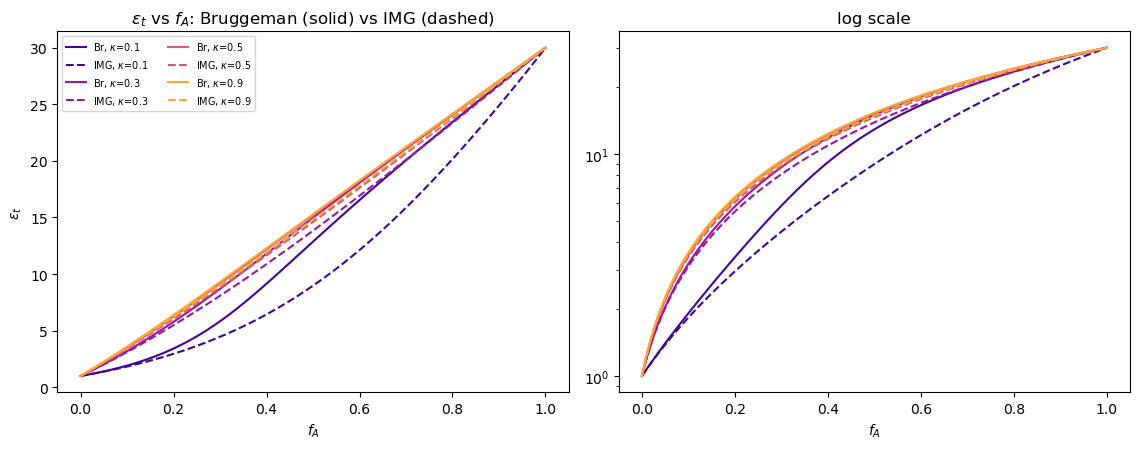

In [13]:
fs = np.linspace(0.0, 1.0, 120)
kappas = (0.10, 0.30, 0.50, 0.90)
cols = plt.cm.plasma(np.linspace(0.1, 0.8, len(kappas)))
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.6))
for k, c in zip(kappas, cols):
    br_t = [br_pair(f, k)[1] for f in fs]
    im_t = [img_pair(f, k)[1] for f in fs]
    for a in ax:
        a.plot(fs, br_t, "-",  color=c, label=rf"Br, $\kappa$={k}")
        a.plot(fs, im_t, "--", color=c, label=rf"IMG, $\kappa$={k}")
ax[0].set_ylabel(r"$\epsilon_t$ "); ax[0].legend(fontsize=7, ncol=2)
ax[1].set_yscale("log"); ax[1].set_title("log scale")
for a in ax: a.set_xlabel(r"$f_A$")
ax[0].set_title(r"$\epsilon_t$ vs $f_A$: Bruggeman (solid) vs IMG (dashed)")
fig.tight_layout(); plt.show()